# ⚠️ DEPRECATED (2026-06-12)

This notebook is superseded by **`GetFMPData/construct_full_data.py`** (+ `util/dataset_builder/`),
which additionally fixes two bugs present here: fundamentals are as-of merged on `filingDate`
instead of period end (look-ahead removed), and liquidity rollings are computed per symbol.

The S3/local paths below are stale after the 2026-06-11 reorganization (raw components moved to
`raw/<label>/`, e.g. `raw/20251229/`; intermediate checkpoints archived/deleted; finals relabeled
`_20251230`). Kept for reference only — do not run.

```bash
python GetFMPData/construct_full_data.py --raw-date <label> --label <label>
```


In [1]:
from dotenv import load_dotenv
load_dotenv()
import os, requests
import numpy as np
import pandas as pd


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


def getFMPData(endpoint, urlhead=None, apikey=None, **params):
    if urlhead is None:
        urlhead = "https://financialmodelingprep.com/stable/"
    if apikey is None:
        apikey = os.getenv("FMP_API_KEY")

    if "from_" in params:
        params["from"] = params.pop("from_")

    url = urlhead + endpoint
    param_lst = [f"apikey={apikey}"] + [str(k) + "=" + str(v) for k, v in params.items()]
    url = "?".join([url, "&".join(param_lst)])
    data = requests.get(url).json()
    return data

In [2]:
!pwd

/home/sagemaker-user/QuantTrading/GetFMPData


In [5]:
os.listdir('data')

['.ipynb_checkpoints',
 'data_adjusteddailyprice_tk0_pd1.parquet',
 'data_adjusteddailyprice_tk0_pd2.parquet',
 'data_adjusteddailyprice_tk0_pd3.parquet',
 'data_unadjusteddailyprice_tk0_pd1.parquet',
 'data_unadjusteddailyprice_tk0_pd2.parquet',
 'data_unadjusteddailyprice_tk0_pd3.parquet',
 'data_incomestatement_tk0_pd1.parquet',
 'data_balancesheet_tk0_pd1.parquet',
 'data_cashflow_tk0_pd1.parquet',
 'data_keymetrics_tk0_pd1.parquet',
 'data_enterprisevalues_tk0_pd1.parquet']

# Price + Profile + EV

## Load Datasets

In [3]:
datatype = 'adjusteddailyprice'
datasets = []
for filename in os.listdir('data'):
    if datatype == filename.split('_')[1]:
        datasets.append(pd.read_parquet(f"data/{filename}"))
adjprice_df = pd.concat(datasets, ignore_index=True)
print(adjprice_df.shape)

datatype = 'unadjusteddailyprice'
datasets = []
for filename in os.listdir('data'):
    if datatype == filename.split('_')[1]:
        datasets.append(pd.read_parquet(f"data/{filename}"))
unadjprice_df = pd.concat(datasets, ignore_index=True)
print(unadjprice_df.shape)

ev_df = pd.read_parquet("data/data_enterprisevalues_tk0_pd1.parquet")
print(ev_df.shape)

# profile_df = pd.read_csv("../MarketInternalMonitor/universe/info-stock-universe-usTrading-delistedIncl.csv")
profile_df = pd.read_parquet("data/data_tickerprofile.parquet")
print(profile_df.shape)

(26198475, 7)
(26198475, 7)
(593349, 8)
(9164, 8)


In [4]:
adjprice_df['symbol'].nunique(), unadjprice_df['symbol'].nunique(), ev_df['symbol'].nunique(), profile_df['symbol'].nunique()

(9100, 9100, 9134, 9164)

In [5]:
# adjprice_df.groupby('symbol').apply(lambda x: pd.Series({
#     'adj_count': x.shape[0],
#     'adj_min': x['date'].min(),
#     'adj_max': x['date'].max(),
# }))

In [9]:
adjprice_df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,NCPL,2009-12-31,140.0,140.0,140.0,140.0,0
1,NCPL,2009-12-30,182.0,182.0,182.0,182.0,1
2,NCPL,2009-12-29,182.0,182.0,182.0,182.0,0
3,NCPL,2009-12-28,140.0,140.0,140.0,140.0,0
4,NCPL,2009-12-24,140.0,140.0,140.0,140.0,0


In [10]:
unadjprice_df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,volume
0,NCPL,2009-12-31,0.0010,0.0010,0.0010,0.0010,0.0
1,NCPL,2009-12-30,0.0013,0.0013,0.0013,0.0013,140000.0
2,NCPL,2009-12-29,0.0013,0.0013,0.0013,0.0013,0.0
3,NCPL,2009-12-28,0.0010,0.0010,0.0010,0.0010,0.0
4,NCPL,2009-12-24,0.0010,0.0010,0.0010,0.0010,0.0


In [11]:
ev_df.head()

,symbol,date,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
0,SNES,2025-09-30,4.39,4668009,20492559.00,7278000.0,2683000.0,15897559.0
1,SNES,2025-06-30,5.09,1854531,9439562.79,6055000.0,2689000.0,6073562.0
2,SNES,2025-03-31,1.81,1299971,2352947.51,1655000.0,248000.0,945947.0
3,SNES,2024-12-31,3.31,729400,2414314.00,1307000.0,262000.0,1369314.0
4,SNES,2024-09-30,2.58,729400,1881852.00,2518000.0,264000.0,-372148.0


In [6]:
profile_df.head()

,symbol,currency,exchange,industry,sector,isActivelyTrading,ipoDate,delistedDate
0,SNES,USD,NASDAQ,Chemicals - Specialty,Basic Materials,True,2016-12-08,NaN
1,OSTX,USD,NYSE,Biotechnology,Healthcare,True,2024-08-01,NaN
2,BGLC,USD,NASDAQ,Medical - Diagnostics & Research,Healthcare,True,2021-01-08,NaN
3,NCPL,USD,NASDAQ,Financial - Capital Markets,Financial Services,True,2006-06-05,NaN
4,CVCO,USD,NASDAQ,Residential Construction,Consumer Cyclical,True,2003-07-01,NaN


In [7]:
profile_df.dtypes

symbol               object
currency             object
exchange             object
industry             object
sector               object
isActivelyTrading      bool
ipoDate              object
delistedDate         object
dtype: object

In [8]:
profile_df['symbol'] = profile_df['symbol'].astype('string')
profile_df['currency'] = profile_df['currency'].astype('string')
profile_df['exchange'] = profile_df['exchange'].astype('string')
profile_df['industry'] = profile_df['industry'].astype('string')
profile_df['sector'] = profile_df['sector'].astype('string')
profile_df['ipoDate'] = pd.to_datetime(profile_df['ipoDate'])
profile_df['delistedDate'] = pd.to_datetime(profile_df['delistedDate'])

In [9]:
profile_df.dtypes

symbol               string[python]
currency             string[python]
exchange             string[python]
industry             string[python]
sector               string[python]
isActivelyTrading              bool
ipoDate              datetime64[ns]
delistedDate         datetime64[ns]
dtype: object

In [11]:
# profile_df.to_parquet(
#     'data/data_tickerprofile.parquet',
#     compression='zstd',
#     index=False
# )

## Merge Prices

In [12]:
unadj = unadjprice_df[['symbol', 'date', 'adjClose', 'volume']].rename(
    columns={'adjClose': 'rawClose', 'volume': 'rawVolume'}
).set_index(['symbol', 'date'])

adj = adjprice_df[['symbol', 'date', 'adjOpen', 'adjHigh', 'adjLow', 'adjClose', 'volume']].rename(
    columns={'volume': 'adjVolume'}
).set_index(['symbol', 'date'])

price = adj.join(unadj, how='outer')
price.sort_index(inplace=True)

print(price.shape)

(26198475, 7)


In [13]:
price.head()

adjOpen  adjHigh  adjLow  adjClose  adjVolume  rawClose  \
symbol date                                                                  
A      2000-01-03    44.23    44.33   37.84     40.44    4962189     67.82   
       2000-01-04    38.26    38.68   36.37     36.82    5058514     61.75   
       2000-01-05    37.22    37.22   33.88     35.04    6113793     58.76   
       2000-01-06    34.62    34.82   32.65     33.14    2690591     55.57   
       2000-01-07    33.17    37.04   33.14     36.51    2993521     61.22   

                    rawVolume  
symbol date                    
A      2000-01-03  3549491.42  
       2000-01-04  3618393.42  
       2000-01-05  4373242.49  
       2000-01-06  1924600.14  
       2000-01-07  2141288.27

In [14]:
price.loc['AAPL']

,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume
date,,,,,,,
2000-01-03,0.78539,0.83875,0.76152,0.83828,535819955,111.94,4.784107e+06
2000-01-04,0.81067,0.82845,0.75778,0.76761,512377600,102.50,4.574800e+06
2000-01-05,0.77697,0.82798,0.77135,0.77884,778322488,104.00,6.949308e+06
2000-01-06,0.79475,0.80131,0.71144,0.71144,767984764,95.00,6.857007e+06
2000-01-07,0.72268,0.75638,0.71519,0.74514,460734748,99.50,4.113703e+06
...,...,...,...,...,...,...,...
2025-12-19,272.15000,274.60000,269.90000,273.67000,144632048,273.67,1.446320e+08
2025-12-22,272.86000,273.88000,270.51000,270.97000,36571827,270.97,3.657183e+07
2025-12-23,270.84000,272.50000,269.56000,272.36000,29642000,272.36,2.964200e+07


## Merge Profile

In [30]:
profile = profile_df[['symbol', 'exchange', 'industry', 'sector', 'ipoDate']]
price = price.reset_index()
price2 = pd.merge(price, profile, how='left', on='symbol')
price2.shape

(26198475, 13)

In [31]:
price2.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18
1,A,2000-01-04,38.26,38.68,36.37,36.82,5058514,61.75,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18
2,A,2000-01-05,37.22,37.22,33.88,35.04,6113793,58.76,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18
3,A,2000-01-06,34.62,34.82,32.65,33.14,2690591,55.57,1924600.14,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18
4,A,2000-01-07,33.17,37.04,33.14,36.51,2993521,61.22,2141288.27,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18


## Merge EV

In [32]:
ev_df

,symbol,date,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
0,SNES,2025-09-30,4.39,4668009,2.049256e+07,7278000.0,2683000.0,1.589756e+07
1,SNES,2025-06-30,5.09,1854531,9.439563e+06,6055000.0,2689000.0,6.073562e+06
2,SNES,2025-03-31,1.81,1299971,2.352948e+06,1655000.0,248000.0,9.459470e+05
3,SNES,2024-12-31,3.31,729400,2.414314e+06,1307000.0,262000.0,1.369314e+06
4,SNES,2024-09-30,2.58,729400,1.881852e+06,2518000.0,264000.0,-3.721480e+05
...,...,...,...,...,...,...,...,...
593344,AENZ,2013-03-31,155.24,37657112,5.845996e+09,653040000.0,925429000.0,6.118385e+09
593345,AENZ,2012-12-31,152.93,37657125,5.759048e+09,780114000.0,845474000.0,5.824408e+09
593346,AENZ,2012-09-30,155.76,37657125,5.865647e+09,556006000.0,0.0,5.309641e+09
593347,AENZ,2012-06-30,159.71,22122707,3.533237e+09,0.0,0.0,3.533237e+09


In [33]:
price2 = price2.sort_values(['date', 'symbol'])
ev2 = ev_df.sort_values(['date', 'symbol'])

df = pd.merge_asof(
    price2,
    ev2,
    by="symbol",
    on="date",
    direction="backward",        # use latest quarter <= daily date
    allow_exact_matches=True
)

df = df.sort_values(['symbol', 'date'])

In [34]:
df.shape

(26198475, 19)

In [35]:
import gc

gc.collect()

133129

In [36]:
df

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue
0,A,2000-01-03,44.2300,44.3300,37.8400,40.4400,4962189,67.8200,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.80,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10
1874,A,2000-01-04,38.2600,38.6800,36.3700,36.8200,5058514,61.7500,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.80,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10
3755,A,2000-01-05,37.2200,37.2200,33.8800,35.0400,6113793,58.7600,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.80,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10
5636,A,2000-01-06,34.6200,34.8200,32.6500,33.1400,2690591,55.5700,1924600.14,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.80,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10
7514,A,2000-01-07,33.1700,37.0400,33.1400,36.5100,2993521,61.2200,2141288.27,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.80,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26161272,ZYXI,2025-12-17,0.3177,0.3600,0.2311,0.2638,4750800,0.2638,4750800.00,NASDAQ,Medical - Distribution,Healthcare,2004-02-25,1.45,30314000.0,4.395530e+07,13259000.0,71618000.0,1.023143e+08
26167495,ZYXI,2025-12-18,0.2511,0.2963,0.2315,0.2800,2279500,0.2800,2279500.00,NASDAQ,Medical - Distribution,Healthcare,2004-02-25,1.45,30314000.0,4.395530e+07,13259000.0,71618000.0,1.023143e+08
26173722,ZYXI,2025-12-19,0.2600,0.3250,0.2426,0.2940,9637200,0.2940,9637200.00,NASDAQ,Medical - Distribution,Healthcare,2004-02-25,1.45,30314000.0,4.395530e+07,13259000.0,71618000.0,1.023143e+08
26179953,ZYXI,2025-12-22,0.3090,0.3500,0.1776,0.1920,6997200,0.1920,6997200.00,NASDAQ,Medical - Distribution,Healthcare,2004-02-25,1.45,30314000.0,4.395530e+07,13259000.0,71618000.0,1.023143e+08


## Build Low Liquidity Filter

In [37]:
df['price_tr20'] = df.rolling(20)['adjClose'].mean()
df['dollarVolume'] = df['rawClose'] * df['rawVolume']
df['dollarVolume_tr20'] = df.rolling(20)['dollarVolume'].mean()
df['turnOver'] = df['adjVolume'] / df['numberOfShares']
df['turnOver_tr20'] = df.rolling(20)['turnOver'].mean()

df['lowLiquidity'] = np.where(
    (df['marketCapitalization'] < 200000000) |
    (df['dollarVolume_tr20'] < 1000000) |
    (df['price_tr20'] < 2) |
    (df['turnOver_tr20'] < 0.0005), 1, 0
)

In [49]:
view = df.groupby('date').apply(lambda x: pd.Series({
    'total tickers': x.shape[0],
    'low marketcap': (x['marketCapitalization'] < 200000000).sum(),
    'low dollarVol': (x['dollarVolume_tr20'] < 1000000).sum(),
    'low price': (x['price_tr20'] < 2).sum(),
    'low turnover': (x['turnOver_tr20'] < 0.0005).sum(),
    'low liquidity': x['lowLiquidity'].sum(),
    'qualified': (x['lowLiquidity']==0).sum()
}))

view

/tmp/ipykernel_145/1709202415.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  view = df.groupby('date').apply(lambda x: pd.Series({


,total tickers,low marketcap,low dollarVol,low price,low turnover,low liquidity,qualified
date,,,,,,,
2000-01-03,1874,649,611,348,135,1090,784
2000-01-04,1881,652,564,290,99,1027,854
2000-01-05,1881,652,533,249,82,982,899
2000-01-06,1878,650,515,217,71,946,932
2000-01-07,1883,652,506,201,60,937,946
...,...,...,...,...,...,...,...
2025-12-19,6227,1900,2212,1100,758,2867,3360
2025-12-22,6231,1905,2215,1100,761,2870,3361
2025-12-23,6228,1901,2214,1097,749,2868,3360


<Axes: xlabel='date'>

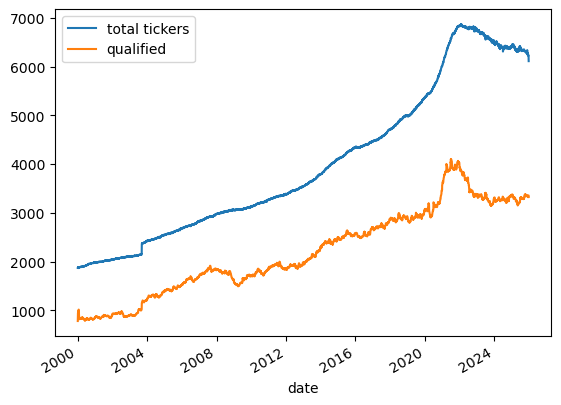

In [55]:
import matplotlib.pyplot as plt

view.loc[view['total tickers']>100, ['total tickers', 'qualified']].plot()

In [54]:
view[view['total tickers']<100]

,total tickers,low marketcap,low dollarVol,low price,low turnover,low liquidity,qualified
date,,,,,,,
2001-09-11,1,0,0,0,0,0,1
2012-10-29,2,0,0,0,0,0,2
2012-10-30,2,0,0,0,0,0,2
2018-12-05,1,0,0,0,0,0,1
2023-01-02,2,0,1,1,0,1,1
2024-07-04,1,1,1,0,1,1,0
2024-09-02,3,2,3,1,2,3,0
2024-11-28,2,2,2,2,1,2,0
2024-12-25,2,1,2,1,2,2,0


## Save Current Dataset

In [38]:
df.shape

(26198475, 25)

In [39]:
df.dtypes

symbol                         string[python]
date                           datetime64[ns]
adjOpen                               float64
adjHigh                               float64
adjLow                                float64
adjClose                              float64
adjVolume                               int64
rawClose                              float64
rawVolume                             float64
exchange                       string[python]
industry                       string[python]
sector                         string[python]
ipoDate                        datetime64[ns]
stockPrice                            float64
numberOfShares                        float64
marketCapitalization                  float64
minusCashAndCashEquivalents           float64
addTotalDebt                          float64
enterpriseValue                       float64
price_tr20                            float64
dollarVolume                          float64
dollarVolume_tr20                 

In [40]:
df.to_parquet(
    "data/data_price-profile-ev.parquet",
    compression='zstd',
    index=False
)

# + Income Statement

## Load Datasets

In [2]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev.parquet"
df = pd.read_parquet(path, engine='pyarrow')
df.shape

(26198475, 25)

In [3]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_incomestatement_tk0_pd1.parquet"
incm_df = pd.read_parquet(path, engine='pyarrow')
incm_df.shape

(590613, 39)

In [4]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0
1,A,2000-01-04,38.26,38.68,36.37,36.82,5058514,61.75,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.234358e+08,NaN,0.011523,NaN,0
2,A,2000-01-05,37.22,37.22,33.88,35.04,6113793,58.76,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.569717e+08,NaN,0.013927,NaN,0
3,A,2000-01-06,34.62,34.82,32.65,33.14,2690591,55.57,1924600.14,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,1.069500e+08,NaN,0.006129,NaN,0
4,A,2000-01-07,33.17,37.04,33.14,36.51,2993521,61.22,2141288.27,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,1.310897e+08,NaN,0.006819,NaN,0


In [11]:
# df.dtypes

In [5]:
incm_df.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2025-09-30,SNES,USD,0001680378,2025-11-10,2025-11-10 17:28:02,2025.0,Q3,690000.0,257000.0,433000.0,400000.0,0.0,0.0,0.0,1380000.0,1780000.0,2037000.0,49000.0,55000.0,6000.0,29000.0,-1263000.0,-1292000.0,-55000.0,-1347000.0,49000.0,-1298000.0,0.0,-1298000.0,0.0,0.0,-1298000.0,0.0,-1298000.0,-0.28,-0.28,4668009.0,4668009.0
1,2025-06-30,SNES,USD,0001680378,2025-08-08,2025-08-07 17:36:07,2025.0,Q2,625000.0,216000.0,409000.0,427000.0,1532000.0,64000.0,1596000.0,0.0,2023000.0,2239000.0,-2000.0,4000.0,6000.0,35000.0,-1575000.0,-1610000.0,-4000.0,-1614000.0,-2000.0,-1616000.0,0.0,-1616000.0,0.0,0.0,-1616000.0,0.0,-1616000.0,-0.87,-0.87,1854531.0,1854531.0
2,2025-03-31,SNES,USD,0001680378,2025-05-08,2025-05-08 17:21:24,2025.0,Q1,485000.0,172000.0,313000.0,418000.0,1494000.0,64000.0,1558000.0,0.0,1976000.0,2148000.0,-2000.0,3000.0,5000.0,39000.0,-1621000.0,-1660000.0,-3000.0,-1663000.0,-2000.0,-1665000.0,0.0,-1665000.0,0.0,0.0,-1665000.0,0.0,-1665000.0,-1.28,-1.28,1299971.0,1299971.0
3,2024-12-31,SNES,USD,0001680378,2025-03-13,2025-03-12 17:38:15,2024.0,Q4,501000.0,196000.0,305000.0,424000.0,1074000.0,64000.0,1138000.0,0.0,1562000.0,1758000.0,1000.0,8000.0,7000.0,41000.0,-1207000.0,-1248000.0,-9000.0,-1257000.0,2000.0,-1255000.0,0.0,-1255000.0,0.0,0.0,-1255000.0,0.0,-1255000.0,-2.07,-2.07,729400.0,729400.0
4,2024-09-30,SNES,USD,0001680378,2024-11-12,2024-11-12 17:23:16,2024.0,Q3,482000.0,167000.0,315000.0,451000.0,1331000.0,80000.0,1411000.0,0.0,1862000.0,2029000.0,5000.0,11000.0,6000.0,42000.0,-1465000.0,-1507000.0,-40000.0,-1547000.0,34000.0,-1513000.0,0.0,-1513000.0,0.0,0.0,-1513000.0,0.0,-1513000.0,-2.07,-2.07,729400.0,729400.0


## Merge Income Statement

In [4]:
incm_cols = [
    'date',
    'symbol',
    'filingDate',
    'acceptedDate',
    'revenue',
    'costOfRevenue',
    'grossProfit',
    'researchAndDevelopmentExpenses',
    'generalAndAdministrativeExpenses',
    'sellingAndMarketingExpenses',
    'sellingGeneralAndAdministrativeExpenses',
    'otherExpenses',
    'operatingExpenses',
    'costAndExpenses',
    'netInterestIncome',
    'interestIncome',
    'interestExpense',
    'depreciationAndAmortization',
    'ebitda',
    'ebit',
    'nonOperatingIncomeExcludingInterest',
    'operatingIncome',
    'totalOtherIncomeExpensesNet',
    'incomeBeforeTax',
    'incomeTaxExpense',
    'netIncomeFromContinuingOperations',
    'netIncomeFromDiscontinuedOperations',
    'otherAdjustmentsToNetIncome',
    'netIncome',
    'netIncomeDeductions',
    'bottomLineNetIncome',
    'eps',
    'epsDiluted',
    'weightedAverageShsOut',
    'weightedAverageShsOutDil'
]

In [16]:
incm_df[incm_cols].dtypes

date                                       datetime64[ns]
symbol                                     string[python]
filingDate                                 datetime64[ns]
acceptedDate                               datetime64[ns]
revenue                                           float64
costOfRevenue                                     float64
grossProfit                                       float64
researchAndDevelopmentExpenses                    float64
generalAndAdministrativeExpenses                  float64
sellingAndMarketingExpenses                       float64
sellingGeneralAndAdministrativeExpenses           float64
otherExpenses                                     float64
operatingExpenses                                 float64
costAndExpenses                                   float64
netInterestIncome                                 float64
interestIncome                                    float64
interestExpense                                   float64
depreciationAn

In [5]:
df.sort_values(['date', 'symbol'], inplace=True)
incm_df.sort_values(['date', 'symbol'], inplace=True)

df = pd.merge_asof(
    df,
    incm_df[incm_cols],
    by="symbol",
    on="date",
    direction="backward",        # use latest quarter <= daily date
    allow_exact_matches=True
)

df.sort_values(['symbol', 'date'], inplace=True)
df.shape

(26198475, 58)

In [6]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,filingDate,acceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
1874,A,2000-01-04,38.26,38.68,36.37,36.82,5058514,61.75,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.234358e+08,NaN,0.011523,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
3755,A,2000-01-05,37.22,37.22,33.88,35.04,6113793,58.76,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.569717e+08,NaN,0.013927,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
5636,A,2000-01-06,34.62,34.82,32.65,33.14,2690591,55.57,1924600.14,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,1.069500e+08,NaN,0.006129,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
7514,A,2000-01-07,33.17,37.04,33.14,36.51,2993521,61.22,2141288.27,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,1.310897e+08,NaN,0.006819,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0


## Save Current Dataset

In [7]:
df.shape

(26198475, 58)

In [8]:
df.dtypes

symbol                                     string[python]
date                                       datetime64[ns]
adjOpen                                           float64
adjHigh                                           float64
adjLow                                            float64
adjClose                                          float64
adjVolume                                           int64
rawClose                                          float64
rawVolume                                         float64
exchange                                   string[python]
industry                                   string[python]
sector                                     string[python]
ipoDate                                    datetime64[ns]
stockPrice                                        float64
numberOfShares                                    float64
marketCapitalization                              float64
minusCashAndCashEquivalents                       float64
addTotalDebt  

In [9]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm.parquet"

df.to_parquet(
    path,
    engine='pyarrow',
    compression='zstd',
    index=False
)

# + Balance Sheet Statement

## Load Datasets

In [2]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm.parquet"
df = pd.read_parquet(path, engine='pyarrow')
df.shape

(26198475, 58)

In [3]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_balancesheet_tk0_pd1.parquet"
bal_df = pd.read_parquet(path, engine='pyarrow')
bal_df.shape

(568517, 61)

In [4]:
df.rename(columns={'filingDate': 'incmFilingDate', 'acceptedDate': 'incmAcceptedDate'}, inplace=True)

In [5]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
1,A,2000-01-04,38.26,38.68,36.37,36.82,5058514,61.75,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.234358e+08,NaN,0.011523,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
2,A,2000-01-05,37.22,37.22,33.88,35.04,6113793,58.76,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.569717e+08,NaN,0.013927,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
3,A,2000-01-06,34.62,34.82,32.65,33.14,2690591,55.57,1924600.14,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,1.069500e+08,NaN,0.006129,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0
4,A,2000-01-07,33.17,37.04,33.14,36.51,2993521,61.22,2141288.27,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,1.310897e+08,NaN,0.006819,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0


In [6]:
bal_df.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,2025-09-30,SNES,USD,0001680378,2025-11-10,2025-11-10 17:28:02,2025.0,Q3,7278000.0,2970000.0,10248000.0,454000.0,454000.0,0.0,767000.0,313000.0,0.0,11782000.0,2806000.0,0.0,0.0,0.0,0.0,0.0,36000.0,2842000.0,0.0,14624000.0,238000.0,238000.0,0.0,333000.0,60000.0,95000.0,0.0,0.0,22000.0,748000.0,160000.0,2368000.0,0.0,0.0,0.0,2528000.0,0.0,2463000.0,3276000.0,0.0,0.0,5000.0,-140676000.0,152019000.0,-2.842171e-08,2.842171e-08,11348000.0,11348000.0,0.0,14624000.0,2970000.0,2683000.0,-4595000.0
1,2025-06-30,SNES,USD,0001680378,2025-08-08,2025-08-07 17:36:07,2025.0,Q2,6055000.0,0.0,6055000.0,470000.0,470000.0,0.0,729000.0,39000.0,181000.0,7474000.0,2833000.0,0.0,0.0,0.0,0.0,0.0,58000.0,2891000.0,0.0,10365000.0,123000.0,123000.0,0.0,310000.0,59000.0,52000.0,0.0,12000.0,254000.0,810000.0,175000.0,2403000.0,0.0,0.0,0.0,2578000.0,0.0,2455000.0,3388000.0,0.0,0.0,4000.0,-139378000.0,146351000.0,0.000000e+00,0.000000e+00,6977000.0,6977000.0,0.0,10365000.0,0.0,2689000.0,-3366000.0
2,2025-03-31,SNES,USD,0001680378,2025-05-08,2025-05-08 17:21:24,2025.0,Q1,1655000.0,0.0,1655000.0,498000.0,498000.0,0.0,753000.0,37000.0,221000.0,3164000.0,404000.0,0.0,0.0,0.0,0.0,0.0,58000.0,462000.0,0.0,3626000.0,164000.0,164000.0,0.0,33000.0,57000.0,0.0,0.0,12000.0,277000.0,543000.0,191000.0,0.0,0.0,0.0,0.0,191000.0,0.0,0.0,734000.0,0.0,0.0,2000.0,-137762000.0,140652000.0,0.000000e+00,0.000000e+00,2892000.0,2892000.0,0.0,3626000.0,0.0,248000.0,-1407000.0
3,2024-12-31,SNES,USD,0001680378,2025-03-13,2025-03-12 17:38:15,2024.0,Q4,1307000.0,0.0,1307000.0,335000.0,335000.0,0.0,794000.0,27000.0,350000.0,2813000.0,407000.0,0.0,0.0,0.0,0.0,0.0,58000.0,465000.0,0.0,3278000.0,215000.0,215000.0,0.0,34000.0,56000.0,0.0,0.0,12000.0,244000.0,561000.0,206000.0,0.0,0.0,0.0,0.0,206000.0,0.0,0.0,767000.0,0.0,0.0,1000.0,-136097000.0,138607000.0,0.000000e+00,0.000000e+00,2511000.0,2511000.0,0.0,3278000.0,0.0,262000.0,-1045000.0
4,2024-09-30,SNES,USD,0001680378,2024-11-12,2024-11-12 17:23:16,2024.0,Q3,2518000.0,0.0,2518000.0,214000.0,214000.0,0.0,880000.0,52000.0,308000.0,3972000.0,419000.0,0.0,0.0,0.0,0.0,0.0,58000.0,477000.0,0.0,4449000.0,128000.0,128000.0,0.0,17000.0,53000.0,41000.0,0.0,12000.0,377000.0,628000.0,170000.0,0.0,0.0,0.0,0.0,170000.0,0.0,41000.0,798000.0,0.0,0.0,1000.0,-134842000.0,138492000.0,0.000000e+00,0.000000e+00,3651000.0,3651000.0,0.0,4449000.0,0.0,264000.0,-2254000.0


## Merge Balance Sheet Statement

In [7]:
bal_cols = [
    'date',
    'symbol',
    'filingDate',
    'acceptedDate',
    'cashAndCashEquivalents',
    'shortTermInvestments',
    'cashAndShortTermInvestments',
    'netReceivables',
    'accountsReceivables',
    'otherReceivables',
    'inventory',
    'prepaids',
    'otherCurrentAssets',
    'totalCurrentAssets',
    'propertyPlantEquipmentNet',
    'goodwill',
    'intangibleAssets',
    'goodwillAndIntangibleAssets',
    'longTermInvestments',
    'taxAssets',
    'otherNonCurrentAssets',
    'totalNonCurrentAssets',
    'otherAssets',
    'totalAssets',
    'totalPayables',
    'accountPayables',
    'otherPayables',
    'accruedExpenses',
    'shortTermDebt',
    'capitalLeaseObligationsCurrent',
    'taxPayables',
    'deferredRevenue',
    'otherCurrentLiabilities',
    'totalCurrentLiabilities',
    'longTermDebt',
    'capitalLeaseObligationsNonCurrent',
    'deferredRevenueNonCurrent',
    'deferredTaxLiabilitiesNonCurrent',
    'otherNonCurrentLiabilities',
    'totalNonCurrentLiabilities',
    'otherLiabilities',
    'capitalLeaseObligations',
    'totalLiabilities',
    'treasuryStock',
    'preferredStock',
    'commonStock',
    'retainedEarnings',
    'additionalPaidInCapital',
    'accumulatedOtherComprehensiveIncomeLoss',
    'otherTotalStockholdersEquity',
    'totalStockholdersEquity',
    'totalEquity',
    'minorityInterest',
    'totalLiabilitiesAndTotalEquity',
    'totalInvestments',
    'totalDebt',
    'netDebt'
]

In [8]:
[x for x in bal_cols[4:] if x in df.columns]

[]

In [9]:
bal_df[bal_cols].dtypes

date                                       datetime64[ns]
symbol                                     string[python]
filingDate                                 datetime64[ns]
acceptedDate                               datetime64[ns]
cashAndCashEquivalents                            float64
shortTermInvestments                              float64
cashAndShortTermInvestments                       float64
netReceivables                                    float64
accountsReceivables                               float64
otherReceivables                                  float64
inventory                                         float64
prepaids                                          float64
otherCurrentAssets                                float64
totalCurrentAssets                                float64
propertyPlantEquipmentNet                         float64
goodwill                                          float64
intangibleAssets                                  float64
goodwillAndInt

In [10]:
df.sort_values(['date', 'symbol'], inplace=True)
bal_df.sort_values(['date', 'symbol'], inplace=True)

df = pd.merge_asof(
    df,
    bal_df[bal_cols],
    by="symbol",
    on="date",
    direction="backward",        # use latest quarter <= daily date
    allow_exact_matches=True
)

df.sort_values(['symbol', 'date'], inplace=True)
df.rename(columns={'filingDate': 'balFilingDate', 'acceptedDate': 'balAcceptedDate'}, inplace=True)
df.shape

(26198475, 113)

In [11]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,balFilingDate,balAcceptedDate,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0,2000-01-25,2000-01-25,0.0,0.0,0.0,1.635000e+09,1.635000e+09,0.0,1.499000e+09,0.0,404000000.0,3.538000e+09,1.387000e+09,0.0,0.0,0.0,0.0,0.0,519000000.0,1.906000e+09,0.0,5.444000e+09,510000000.0,510000000.0,0.0,0.0,0.0,0.0,0.0,241000000.0,930000000.0,1.681000e+09,0.0,0.0,0.0,0.0,381000000.0,381000000.0,0.0,0.0,2.062000e+09,0.0,0.0,4000000.0,0.0,3.378000e+09,0.0,0.0,3.382000e+09,3.382000e+09,0.0,5.444000e+09,0.0,0.0,0.0
1874,A,2000-01-04,38.26,38.68,36.37,36.82,5058514,61.75,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.234358e+08,NaN,0.011523,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0,2000-01-25,2000-01-25,0.0,0.0,0.0,1.635000e+09,1.635000e+09,0.0,1.499000e+09,0.0,404000000.0,3.538000e+09,1.387000e+09,0.0,0.0,0.0,0.0,0.0,519000000.0,1.906000e+09,0.0,5.444000e+09,510000000.0,510000000.0,0.0,0.0,0.0,0.0,0.0,241000000.0,930000000.0,1.681000e+09,0.0,0.0,0.0,0.0,381000000.0,381000000.0,0.0,0.0,2.062000e+09,0.0,0.0,4000000.0,0.0,3.378000e+09,0.0,0.0,3.382000e+09,3.382000e+09,0.0,5.444000e+09,0.0,0.0,0.0
3755,A,2000-01-05,37.22,37.22,33.88,35.04,6113793,58.76,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.

## Save Current Dataset

In [12]:
df.shape

(26198475, 113)

In [15]:
df.dtypes.value_counts()

float64           101
datetime64[ns]      6
string[python]      4
int64               2
Name: count, dtype: int64

In [16]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm-bal.parquet"

df.to_parquet(
    path,
    engine='pyarrow',
    compression='zstd',
    index=False
)

# + Cashflow Statement

## Load Datasets

In [2]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm-bal.parquet"
df = pd.read_parquet(path, engine='pyarrow')
df.shape

(26198475, 113)

In [3]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_cashflow_tk0_pd1.parquet"
cf_df = pd.read_parquet(path, engine='pyarrow')
cf_df.shape

(563270, 47)

In [4]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,depreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,balFilingDate,balAcceptedDate,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,accountsReceivables,otherReceivables,inventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0,2000-01-25,2000-01-25,0.0,0.0,0.0,1.635000e+09,1.635000e+09,0.0,1.499000e+09,0.0,404000000.0,3.538000e+09,1.387000e+09,0.0,0.0,0.0,0.0,0.0,519000000.0,1.906000e+09,0.0,5.444000e+09,510000000.0,510000000.0,0.0,0.0,0.0,0.0,0.0,241000000.0,930000000.0,1.681000e+09,0.0,0.0,0.0,0.0,381000000.0,381000000.0,0.0,0.0,2.062000e+09,0.0,0.0,4000000.0,0.0,3.378000e+09,0.0,0.0,3.382000e+09,3.382000e+09,0.0,5.444000e+09,0.0,0.0,0.0
1,A,2000-01-04,38.26,38.68,36.37,36.82,5058514,61.75,3618393.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.234358e+08,NaN,0.011523,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0,2000-01-25,2000-01-25,0.0,0.0,0.0,1.635000e+09,1.635000e+09,0.0,1.499000e+09,0.0,404000000.0,3.538000e+09,1.387000e+09,0.0,0.0,0.0,0.0,0.0,519000000.0,1.906000e+09,0.0,5.444000e+09,510000000.0,510000000.0,0.0,0.0,0.0,0.0,0.0,241000000.0,930000000.0,1.681000e+09,0.0,0.0,0.0,0.0,381000000.0,381000000.0,0.0,0.0,2.062000e+09,0.0,0.0,4000000.0,0.0,3.378000e+09,0.0,0.0,3.382000e+09,3.382000e+09,0.0,5.444000e+09,0.0,0.0,0.0
2,A,2000-01-05,37.22,37.22,33.88,35.04,6113793,58.76,4373242.49,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.569717

In [5]:
cf_df.head()

,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,netIncome,depreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,accountsReceivables,inventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
0,2025-09-30,SNES,USD,0001680378,2025-11-10,2025-11-10 17:28:02,2025.0,Q3,-1298000.0,29000.0,0.0,0.0,-324000.0,16000.0,-56000.0,0.0,-284000.0,214000.0,-1379000.0,-42000.0,0.0,0.0,0.0,-2964000.0,-3006000.0,-14000.0,-14000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5622000.0,5608000.0,0.0,1223000.0,7278000.0,6055000.0,-1379000.0,-42000.0,-1421000.0,0.0,6000.0
1,2025-06-30,SNES,USD,0001680378,2025-08-08,2025-08-07 17:36:07,2025.0,Q2,-1616000.0,35000.0,0.0,90000.0,297000.0,22000.0,42000.0,-41000.0,274000.0,44000.0,-1150000.0,-47000.0,0.0,0.0,0.0,0.0,-47000.0,-14000.0,-14000.0,0.0,5611000.0,5611000.0,5611000.0,0.0,0.0,0.0,0.0,0.0,0.0,5597000.0,0.0,4400000.0,6055000.0,1655000.0,-1150000.0,-47000.0,-1197000.0,0.0,0.0
2,2025-03-31,SNES,USD,0001680378,2025-05-08,2025-05-08 17:21:24,2025.0,Q1,-1665000.0,39000.0,0.0,91000.0,-22000.0,-163000.0,41000.0,-51000.0,151000.0,0.0,-1557000.0,-36000.0,0.0,0.0,0.0,0.0,-36000.0,-14000.0,-14000.0,0.0,1066000.0,1066000.0,1066000.0,0.0,0.0,0.0,0.0,0.0,889000.0,1941000.0,0.0,348000.0,1655000.0,1307000.0,-1557000.0,-36000.0,-1593000.0,0.0,5000.0
3,2024-12-31,SNES,USD,0001680378,2025-03-13,2025-03-12 17:38:15,2024.0,Q4,-1255000.0,41000.0,0.0,80000.0,-84000.0,-121000.0,86000.0,87000.0,-136000.0,0.0,-1218000.0,-15000.0,0.0,0.0,0.0,0.0,-15000.0,-13000.0,-13000.0,0.0,38000.0,38000.0,38000.0,0.0,0.0,0.0,0.0,0.0,-3000.0,22000.0,0.0,-1211000.0,1307000.0,2518000.0,-1218000.0,-15000.0,-1233000.0,0.0,7000.0
4,2024-09-30,SNES,USD,0001680378,2024-11-12,2024-11-12 17:23:16,2024.0,Q3,-1513000.0,42000.0,0.0,73000.0,24000.0,29000.0,19000.0,-63000.0,39000.0,-25000.0,-1399000.0,-28000.0,0.0,0.0,0.0,28000.0,0.0,-12000.0,-12000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1977000.0,1965000.0,0.0,566000.0,2518000.0,1952000.0,-1399000.0,-28000.0,-1427000.0,0.0,6000.0


## Merge Balance Sheet Statement

In [6]:
cf_df.loc[:10, 'netIncome':].columns.tolist()

['netIncome',
 'depreciationAndAmortization',
 'deferredIncomeTax',
 'stockBasedCompensation',
 'changeInWorkingCapital',
 'accountsReceivables',
 'inventory',
 'accountsPayables',
 'otherWorkingCapital',
 'otherNonCashItems',
 'netCashProvidedByOperatingActivities',
 'investmentsInPropertyPlantAndEquipment',
 'acquisitionsNet',
 'purchasesOfInvestments',
 'salesMaturitiesOfInvestments',
 'otherInvestingActivities',
 'netCashProvidedByInvestingActivities',
 'netDebtIssuance',
 'longTermNetDebtIssuance',
 'shortTermNetDebtIssuance',
 'netStockIssuance',
 'netCommonStockIssuance',
 'commonStockIssuance',
 'commonStockRepurchased',
 'netPreferredStockIssuance',
 'netDividendsPaid',
 'commonDividendsPaid',
 'preferredDividendsPaid',
 'otherFinancingActivities',
 'netCashProvidedByFinancingActivities',
 'effectOfForexChangesOnCash',
 'netChangeInCash',
 'cashAtEndOfPeriod',
 'cashAtBeginningOfPeriod',
 'operatingCashFlow',
 'capitalExpenditure',
 'freeCashFlow',
 'incomeTaxesPaid',
 'intere

In [7]:
cf_cols = [
    'date',
    'symbol',
    'filingDate',
    'acceptedDate',
    'netIncome',
    'depreciationAndAmortization',
    'deferredIncomeTax',
    'stockBasedCompensation',
    'changeInWorkingCapital',
    'accountsReceivables',
    'inventory',
    'accountsPayables',
    'otherWorkingCapital',
    'otherNonCashItems',
    'netCashProvidedByOperatingActivities',
    'investmentsInPropertyPlantAndEquipment',
    'acquisitionsNet',
    'purchasesOfInvestments',
    'salesMaturitiesOfInvestments',
    'otherInvestingActivities',
    'netCashProvidedByInvestingActivities',
    'netDebtIssuance',
    'longTermNetDebtIssuance',
    'shortTermNetDebtIssuance',
    'netStockIssuance',
    'netCommonStockIssuance',
    'commonStockIssuance',
    'commonStockRepurchased',
    'netPreferredStockIssuance',
    'netDividendsPaid',
    'commonDividendsPaid',
    'preferredDividendsPaid',
    'otherFinancingActivities',
    'netCashProvidedByFinancingActivities',
    'effectOfForexChangesOnCash',
    'netChangeInCash',
    'cashAtEndOfPeriod',
    'cashAtBeginningOfPeriod',
    'operatingCashFlow',
    'capitalExpenditure',
    'freeCashFlow',
    'incomeTaxesPaid',
    'interestPaid'
]

In [8]:
dup_cols = [x for x in cf_cols[4:] if x in df.columns]
dup_cols

['netIncome',
 'depreciationAndAmortization',
 'accountsReceivables',
 'inventory']

In [9]:
df.rename(columns={
    'netIncome': 'incmNetIncome',
    'depreciationAndAmortization': 'incmDepreciationAndAmortization',
    'accountsReceivables': 'balAccountsReceivables',
    'inventory': 'balInventory'
}, inplace=True)

In [10]:
[x for x in cf_cols[4:] if x in df.columns]

[]

In [19]:
# df.loc[df['symbol']=='SNES', ['symbol', 'date'] + dup_cols]

In [20]:
# cf_df.loc[cf_df['symbol']=='SNES', ['symbol', 'date'] + dup_cols]

In [11]:
cf_df[cf_cols].dtypes

date                                      datetime64[ns]
symbol                                    string[python]
filingDate                                datetime64[ns]
acceptedDate                              datetime64[ns]
netIncome                                        float64
depreciationAndAmortization                      float64
deferredIncomeTax                                float64
stockBasedCompensation                           float64
changeInWorkingCapital                           float64
accountsReceivables                              float64
inventory                                        float64
accountsPayables                                 float64
otherWorkingCapital                              float64
otherNonCashItems                                float64
netCashProvidedByOperatingActivities             float64
investmentsInPropertyPlantAndEquipment           float64
acquisitionsNet                                  float64
purchasesOfInvestments         

In [12]:
df.sort_values(['date', 'symbol'], inplace=True)
cf_df.sort_values(['date', 'symbol'], inplace=True)

df = pd.merge_asof(
    df,
    cf_df[cf_cols],
    by="symbol",
    on="date",
    direction="backward",        # use latest quarter <= daily date
    allow_exact_matches=True
)

df.sort_values(['symbol', 'date'], inplace=True)
df.rename(columns={
    'filingDate': 'cfFilingDate',
    'acceptedDate': 'cfAcceptedDate',
    'netIncome': 'cfNetIncome',
    'depreciationAndAmortization': 'cfDepreciationAndAmortization',
    'accountsReceivables': 'cfAccountsReceivables',
    'inventory': 'cfInventory'
}, inplace=True)
df.shape

(26198475, 154)

In [13]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,incmDepreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,incmNetIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,balFilingDate,balAcceptedDate,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,balAccountsReceivables,otherReceivables,balInventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,cfFilingDate,cfAcceptedDate,cfNetIncome,cfDepreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,cfAccountsReceivables,cfInventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0,2000-01-25,2000-01-25,0.0,0.0,0.0,1.635000e+09,1.635000e+09,0.0,1.499000e+09,0.0,404000000.0,3.538000e+09,1.387000e+09,0.0,0.0,0.0,0.0,0.0,519000000.0,1.906000e+09,0.0,5.444000e+09,510000000.0,510000000.0,0.0,0.0,0.0,0.0,0.0,241000000.0,930000000.0,1.681000e+09,0.0,0.0,0.0,0.0,381000000.0,381000000.0,0.0,0.0,2.062000e+09,0.0,0.0,4000000.0,0.0,3.378000e+09,0.0,0.0,3.382000e+09,3.382000e+09,0.0,5.444000e+09,0.0,0.0,0.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1874,A,2000-01-04,38.26,

## Save Current Dataset

In [16]:
df.shape

(26198475, 154)

In [17]:
df.dtypes.value_counts()

float64           140
datetime64[ns]      8
string[python]      4
int64               2
Name: count, dtype: int64

In [18]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm-bal-cf.parquet"

df.to_parquet(
    path,
    engine='pyarrow',
    compression='zstd',
    index=False
)

# + KeyMetrics Statement

## Load Datasets

In [2]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm-bal-cf.parquet"
df = pd.read_parquet(path, engine='pyarrow')
df.shape

(26198475, 154)

In [20]:
df.shape

(26198475, 154)

In [3]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_keymetrics_tk0_pd1.parquet"
km_df = pd.read_parquet(path, engine='pyarrow')
km_df.shape

(593349, 47)

In [4]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,enterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,incmDepreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,incmNetIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,balFilingDate,balAcceptedDate,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,balAccountsReceivables,otherReceivables,balInventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,cfFilingDate,cfAcceptedDate,cfNetIncome,cfDepreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,cfAccountsReceivables,cfInventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e+09,2.448000e+09,2.448000e+09,0.0,0.0,0.0,0.0,-5.142000e+09,-5.142000e+09,0.0,-5.142000e+09,5.142000e+09,0.0,0.0,146000000.0,0.0,0.0,146000000.0,0.0,146000000.0,0.33,0.33,439000000.0,440000000.0,2000-01-25,2000-01-25,0.0,0.0,0.0,1.635000e+09,1.635000e+09,0.0,1.499000e+09,0.0,404000000.0,3.538000e+09,1.387000e+09,0.0,0.0,0.0,0.0,0.0,519000000.0,1.906000e+09,0.0,5.444000e+09,510000000.0,510000000.0,0.0,0.0,0.0,0.0,0.0,241000000.0,930000000.0,1.681000e+09,0.0,0.0,0.0,0.0,381000000.0,381000000.0,0.0,0.0,2.062000e+09,0.0,0.0,4000000.0,0.0,3.378000e+09,0.0,0.0,3.382000e+09,3.382000e+09,0.0,5.444000e+09,0.0,0.0,0.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,2000-01-04,38.26,38.

In [5]:
km_df.head()

,symbol,date,fiscalYear,period,reportedCurrency,marketCap,enterpriseValue,evToSales,evToOperatingCashFlow,evToFreeCashFlow,evToEBITDA,netDebtToEBITDA,currentRatio,incomeQuality,grahamNetNet,taxBurden,interestBurden,workingCapital,investedCapital,returnOnAssets,operatingReturnOnAssets,returnOnTangibleAssets,returnOnEquity,returnOnInvestedCapital,returnOnCapitalEmployed,earningsYield,freeCashFlowYield,capexToOperatingCashFlow,capexToDepreciation,capexToRevenue,salesGeneralAndAdministrativeToRevenue,researchAndDevelopementToRevenue,stockBasedCompensationToRevenue,intangiblesToTotalAssets,averageReceivables,averagePayables,averageInventory,daysOfSalesOutstanding,daysOfPayablesOutstanding,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,grahamNumber
0,SNES,2025-09-30,2025.0,Q3,USD,20492559.51,15897559.51,23.039941,-11.528325,-11.187586,-12.587141,3.638163,15.751337,1.062404,1.648669,1.0,1.004644,11034000.0,13840000.0,-0.088758,-0.107807,-0.088758,-0.114381,-0.096002,-0.097074,-0.063340,-0.069342,-0.030457,1.448276,0.060870,0.000000,0.579710,0.000000,0.0,462000.0,180500.0,748000.0,59.217391,83.346304,268.599222,327.816613,244.470310,3174000.0,-5675000.0,11348000.0,8506000.0,NaN
1,SNES,2025-06-30,2025.0,Q2,USD,9439562.79,6073562.79,9.717700,-5.281359,-5.073987,-3.856230,2.137143,9.227160,0.711634,1.824720,1.0,1.003727,6664000.0,9497000.0,-0.155909,-0.230720,-0.155909,-0.231618,-0.166977,-0.168917,-0.171194,-0.126807,-0.040870,1.342857,0.075200,2.451200,0.683200,0.144000,0.0,484000.0,143500.0,741000.0,67.680000,51.250000,303.750000,371.430000,320.180000,2169000.0,-5665000.0,6977000.0,4086000.0,NaN
2,SNES,2025-03-31,2025.0,Q1,USD,2352947.51,945947.51,1.950407,-0.607545,-0.593815,-0.583558,0.867983,5.826888,0.935135,1.285413,1.0,1.003012,2621000.0,3025000.0,-0.459184,-0.481750,-0.459184,-0.575726,-0.529618,-0.539410,-0.707623,-0.677023,-0.023121,0.923077,0.074227,3.080412,0.861856,0.187629,0.0,416500.0,189500.0,773500.0,92.412371,85.813953,394.011628,486.423999,400.610046,-186000.0,-2026000.0,2892000.0,2430000.0,NaN
3,SNES,2024-12-31,2024.0,Q4,USD,2414314.00,1369314.00,2.733162,-1.124232,-1.110555,-1.134477,0.865783,5.014260,0.970518,1.629079,1.0,1.005609,2252000.0,2659000.0,-0.382855,-0.325353,-0.382855,-0.499801,-0.453300,-0.462643,-0.519816,-0.510704,-0.012315,0.365854,0.029940,2.143713,0.846307,0.159681,0.0,274500.0,171500.0,837000.0,60.179641,98.724490,364.591837,424.771477,326.046988,-188000.0,-130000.0,2511000.0,2046000.0,NaN
4,SNES,2024-09-30,2024.0,Q3,USD,1881852.00,-372148.00,-0.772091,0.266010,0.260790,0.254026,1.538567,6.324841,0.924653,3.181382,1.0,1.003981,3344000.0,3763000.0,-0.340076,-0.364601,-0.340076,-0.414407,-0.395147,-0.404868,-0.803995,-0.758296,-0.020014,0.666667,0.058091,2.761411,0.935685,0.151452,0.0,228500.0,159500.0,889500.0,39.958506,68.982036,474.251497,514.210003,445.227967,827000.0,-2040000.0,3651000.0,3174000.0,NaN


## Merge Balance Sheet Statement

In [6]:
km_df.loc[:10, 'marketCap':].columns.tolist()

['marketCap',
 'enterpriseValue',
 'evToSales',
 'evToOperatingCashFlow',
 'evToFreeCashFlow',
 'evToEBITDA',
 'netDebtToEBITDA',
 'currentRatio',
 'incomeQuality',
 'grahamNetNet',
 'taxBurden',
 'interestBurden',
 'workingCapital',
 'investedCapital',
 'returnOnAssets',
 'operatingReturnOnAssets',
 'returnOnTangibleAssets',
 'returnOnEquity',
 'returnOnInvestedCapital',
 'returnOnCapitalEmployed',
 'earningsYield',
 'freeCashFlowYield',
 'capexToOperatingCashFlow',
 'capexToDepreciation',
 'capexToRevenue',
 'salesGeneralAndAdministrativeToRevenue',
 'researchAndDevelopementToRevenue',
 'stockBasedCompensationToRevenue',
 'intangiblesToTotalAssets',
 'averageReceivables',
 'averagePayables',
 'averageInventory',
 'daysOfSalesOutstanding',
 'daysOfPayablesOutstanding',
 'daysOfInventoryOutstanding',
 'operatingCycle',
 'cashConversionCycle',
 'freeCashFlowToEquity',
 'freeCashFlowToFirm',
 'tangibleAssetValue',
 'netCurrentAssetValue',
 'grahamNumber']

In [7]:
km_cols = [
    'date',
    'symbol',
    'marketCap',
    'enterpriseValue',
    'evToSales',
    'evToOperatingCashFlow',
    'evToFreeCashFlow',
    'evToEBITDA',
    'netDebtToEBITDA',
    'currentRatio',
    'incomeQuality',
    'grahamNetNet',
    'taxBurden',
    'interestBurden',
    'workingCapital',
    'investedCapital',
    'returnOnAssets',
    'operatingReturnOnAssets',
    'returnOnTangibleAssets',
    'returnOnEquity',
    'returnOnInvestedCapital',
    'returnOnCapitalEmployed',
    'earningsYield',
    'freeCashFlowYield',
    'capexToOperatingCashFlow',
    'capexToDepreciation',
    'capexToRevenue',
    'salesGeneralAndAdministrativeToRevenue',
    'researchAndDevelopementToRevenue',
    'stockBasedCompensationToRevenue',
    'intangiblesToTotalAssets',
    'averageReceivables',
    'averagePayables',
    'averageInventory',
    'daysOfSalesOutstanding',
    'daysOfPayablesOutstanding',
    'daysOfInventoryOutstanding',
    'operatingCycle',
    'cashConversionCycle',
    'freeCashFlowToEquity',
    'freeCashFlowToFirm',
    'tangibleAssetValue',
    'netCurrentAssetValue',
    'grahamNumber'
]

In [8]:
dup_cols = [x for x in km_cols[2:] if x in df.columns]
dup_cols

['enterpriseValue']

In [15]:
df.rename(columns={
    'enterpriseValue': 'evEnterpriseValue',
}, inplace=True)

In [16]:
[x for x in km_cols[2:] if x in df.columns]

[]

In [17]:
km_df[km_cols].dtypes

date                                      datetime64[ns]
symbol                                    string[python]
marketCap                                        float64
enterpriseValue                                  float64
evToSales                                        float64
evToOperatingCashFlow                            float64
evToFreeCashFlow                                 float64
evToEBITDA                                       float64
netDebtToEBITDA                                  float64
currentRatio                                     float64
incomeQuality                                    float64
grahamNetNet                                     float64
taxBurden                                        float64
interestBurden                                   float64
workingCapital                                   float64
investedCapital                                  float64
returnOnAssets                                   float64
operatingReturnOnAssets        

In [18]:
df.sort_values(['date', 'symbol'], inplace=True)
km_df.sort_values(['date', 'symbol'], inplace=True)

df = pd.merge_asof(
    df,
    km_df[km_cols],
    by="symbol",
    on="date",
    direction="backward",        # use latest quarter <= daily date
    allow_exact_matches=True
)

df.sort_values(['symbol', 'date'], inplace=True)
df.rename(columns={
    'enterpriseValue': 'kmEnterpriseValue',
}, inplace=True)
df.shape

(26198475, 196)

In [19]:
df.head()

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,evEnterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,incmDepreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,incmNetIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,balFilingDate,balAcceptedDate,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,balAccountsReceivables,otherReceivables,balInventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,cfFilingDate,cfAcceptedDate,cfNetIncome,cfDepreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,cfAccountsReceivables,cfInventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid,marketCap,kmEnterpriseValue,evToSales,evToOperatingCashFlow,evToFreeCashFlow,evToEBITDA,netDebtToEBITDA,currentRatio,incomeQuality,grahamNetNet,taxBurden,interestBurden,workingCapital,investedCapital,returnOnAssets,operatingReturnOnAssets,returnOnTangibleAssets,returnOnEquity,returnOnInvestedCapital,returnOnCapitalEmployed,earningsYield,freeCashFlowYield,capexToOperatingCashFlow,capexToDepreciation,capexToRevenue,salesGeneralAndAdministrativeToRevenue,researchAndDevelopementToRevenue,stockBasedCompensationToRevenue,intangiblesToTotalAssets,averageReceivables,averagePayables,averageInventory,daysOfSalesOutstanding,daysOfPayablesOutstanding,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,grahamNumber
0,A,2000-01-03,44.23,44.33,37.84,40.44,4962189,67.82,3549491.42,NYSE,Medical - Diagnostics & Research,Healthcare,1999-11-18,28.8,439000000.0,1.264320e+10,0.0,0.0,1.264320e+10,NaN,2.407265e+08,NaN,0.011303,NaN,0,2000-01-25,2000-01-25,2.448000e+09,0.0,2.448000e+09,0.0,0.0,0.0,0.0,2.448000e

## Save Current Dataset

In [20]:
df.shape

(26198475, 196)

In [21]:
df.dtypes.value_counts()

float64           182
datetime64[ns]      8
string[python]      4
int64               2
Name: count, dtype: int64

In [22]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm-bal-cf-km.parquet"

df.to_parquet(
    path,
    engine='pyarrow',
    compression='zstd',
    index=False
)

# Create Sample Data for Pipeline Build

In [26]:
sample_tickers = df['symbol'].drop_duplicates().sample(100).tolist()
sample_tickers

['MSPR',
 'T-PC',
 'REIS',
 'HOVRW',
 'MEHA',
 'EMBKW',
 'EVOP',
 'PPC',
 'PRG',
 'IVC',
 'WSFS',
 'VZLA',
 'UP-WT',
 'STBX',
 'VRSK',
 'RAVN',
 'QCLS',
 'JKHY',
 'WBS-PG',
 'LRN',
 'JEM',
 'FLEX',
 'PEB-PF',
 'BMRA',
 'ASPI',
 'NOTV',
 'OPK',
 'VLDRW',
 'OKSB',
 'PEB-PE',
 'WOR',
 'WPCA-WT',
 'PSA-PG',
 'PFS',
 'KRNY',
 'HCKT',
 'NTRA',
 'GAMB',
 'AVRO',
 'BTOG',
 'KNSA',
 'ADUR',
 'EVTV',
 'MET-PA',
 'AZZ',
 'HTLM',
 'DC',
 'TXO',
 'CMRE-PB',
 'HEXO',
 'AMT',
 'NET',
 'DDL',
 'PPG',
 'LAB',
 'SPRO',
 'LTHM',
 'BDCIW',
 'VECT',
 'FLMN',
 'LSBPW',
 'HSC',
 'ZAPP',
 'ECC-PD',
 'VIVO',
 'SEMR',
 'KBSX',
 'AQNB',
 'MBC',
 'RMR',
 'THC',
 'NUVA',
 'MDWD',
 'PUK',
 'ETAO',
 'NOG',
 'AZUR',
 'MDC',
 'RILYZ',
 'OFSSH',
 'XPEV',
 'BLBX',
 'OIIM',
 'SUIG',
 'SIVBP',
 'ABAT',
 'FRBA',
 'TRT',
 'DSP',
 'TRCA-WT',
 'AEVA-WT',
 'CSII',
 'QSR',
 'GMCR',
 'Y',
 'ATHA',
 'RAPT',
 'CAI',
 'TILE',
 'ZK']

In [27]:
sample_df = df[df['symbol'].isin(sample_tickers)]
sample_df

,symbol,date,adjOpen,adjHigh,adjLow,adjClose,adjVolume,rawClose,rawVolume,exchange,industry,sector,ipoDate,stockPrice,numberOfShares,marketCapitalization,minusCashAndCashEquivalents,addTotalDebt,evEnterpriseValue,price_tr20,dollarVolume,dollarVolume_tr20,turnOver,turnOver_tr20,lowLiquidity,incmFilingDate,incmAcceptedDate,revenue,costOfRevenue,grossProfit,researchAndDevelopmentExpenses,generalAndAdministrativeExpenses,sellingAndMarketingExpenses,sellingGeneralAndAdministrativeExpenses,otherExpenses,operatingExpenses,costAndExpenses,netInterestIncome,interestIncome,interestExpense,incmDepreciationAndAmortization,ebitda,ebit,nonOperatingIncomeExcludingInterest,operatingIncome,totalOtherIncomeExpensesNet,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,incmNetIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil,balFilingDate,balAcceptedDate,cashAndCashEquivalents,shortTermInvestments,cashAndShortTermInvestments,netReceivables,balAccountsReceivables,otherReceivables,balInventory,prepaids,otherCurrentAssets,totalCurrentAssets,propertyPlantEquipmentNet,goodwill,intangibleAssets,goodwillAndIntangibleAssets,longTermInvestments,taxAssets,otherNonCurrentAssets,totalNonCurrentAssets,otherAssets,totalAssets,totalPayables,accountPayables,otherPayables,accruedExpenses,shortTermDebt,capitalLeaseObligationsCurrent,taxPayables,deferredRevenue,otherCurrentLiabilities,totalCurrentLiabilities,longTermDebt,capitalLeaseObligationsNonCurrent,deferredRevenueNonCurrent,deferredTaxLiabilitiesNonCurrent,otherNonCurrentLiabilities,totalNonCurrentLiabilities,otherLiabilities,capitalLeaseObligations,totalLiabilities,treasuryStock,preferredStock,commonStock,retainedEarnings,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt,cfFilingDate,cfAcceptedDate,cfNetIncome,cfDepreciationAndAmortization,deferredIncomeTax,stockBasedCompensation,changeInWorkingCapital,cfAccountsReceivables,cfInventory,accountsPayables,otherWorkingCapital,otherNonCashItems,netCashProvidedByOperatingActivities,investmentsInPropertyPlantAndEquipment,acquisitionsNet,purchasesOfInvestments,salesMaturitiesOfInvestments,otherInvestingActivities,netCashProvidedByInvestingActivities,netDebtIssuance,longTermNetDebtIssuance,shortTermNetDebtIssuance,netStockIssuance,netCommonStockIssuance,commonStockIssuance,commonStockRepurchased,netPreferredStockIssuance,netDividendsPaid,commonDividendsPaid,preferredDividendsPaid,otherFinancingActivities,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid,marketCap,kmEnterpriseValue,evToSales,evToOperatingCashFlow,evToFreeCashFlow,evToEBITDA,netDebtToEBITDA,currentRatio,incomeQuality,grahamNetNet,taxBurden,interestBurden,workingCapital,investedCapital,returnOnAssets,operatingReturnOnAssets,returnOnTangibleAssets,returnOnEquity,returnOnInvestedCapital,returnOnCapitalEmployed,earningsYield,freeCashFlowYield,capexToOperatingCashFlow,capexToDepreciation,capexToRevenue,salesGeneralAndAdministrativeToRevenue,researchAndDevelopementToRevenue,stockBasedCompensationToRevenue,intangiblesToTotalAssets,averageReceivables,averagePayables,averageInventory,daysOfSalesOutstanding,daysOfPayablesOutstanding,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,grahamNumber
11962158,ABAT,2016-02-24,5.25,5.25,5.25,5.25,200,0.35,3000.0,NASDAQ,Industrial Materials,Basic Materials,2016-02-24,5.25,2666666.0,1.400000e+07,1.212800e+04,1.018050e+05,1.408967e+07,38.5860,1050.00,8.176596e+06,0.000075,0.001828,1,2015-12-31,2015-12-30 19:00:00,0.000000e+00,0.000000e+00

In [30]:
sample_df.groupby('symbol').apply(lambda x: pd.Series({
    'total #': x.shape[0],
    'qualified #': (x['lowLiquidity']==0).sum(),
    'qualified %': (x['lowLiquidity']==0).mean(),
}))

/tmp/ipykernel_855/1395750711.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df.groupby('symbol').apply(lambda x: pd.Series({


,total #,qualified #,qualified %
symbol,,,
ABAT,2476.0,541.0,0.218498
ADUR,302.0,151.0,0.500000
AEVA-WT,581.0,34.0,0.058520
AMT,6536.0,6441.0,0.985465
AQNB,1657.0,0.0,0.000000
ASPI,784.0,248.0,0.316327
ATHA,1325.0,448.0,0.338113
AVRO,1510.0,695.0,0.460265
AZUR,257.0,9.0,0.035019


In [31]:
sample_df.shape

(275933, 196)

In [32]:
sample_df.dtypes.value_counts()

float64           182
datetime64[ns]      8
string[python]      4
int64               2
Name: count, dtype: int64

In [33]:
path = "s3://sagemaker-us-east-1-209479286572/datasets/QuantTradingModelData/data_price-profile-ev-incm-bal-cf-km_sampled100.parquet"

sample_df.to_parquet(
    path,
    engine='pyarrow',
    compression='zstd',
    index=False
)